In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
import sys
import glob
import itertools as it
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['font.family'] = 'serif'
import seaborn as sns

import gwpy.table
import cogwheel.cosmology
from cogwheel import utils, gw_plotting, plotting
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
import helpers

/home/abbye.williams/venv/gwaves_pe/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


### compare $\ln\mathcal L$ of the truth (injected pars) to the posterior `'lnl'` column

We want to flag failures on $\Delta = \ln\bar{\mathcal L}(\vec\theta_\mathrm{true}) - \ln\bar{\mathcal L}_\mathrm{max,lensed}$.
Healthy sampling should have $\Delta < 0$, since the sampler should be able to find a set of parameters that is a better fit to the data (due to noise) than the injected parameters.
If $\Delta > 0$, that's a good sign that the PE failed.

In [5]:
# parameters
approximant = 'IMRPhenomXPHM'
prior_class = 'IntrinsicLVCPrior'
# get the SNR and compute the Bayes factor
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/{prior_class}'
seed = 12

In [5]:
# load one sample
idx = 3
eventname = f'GW{seed}_{idx}'
event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
# what's the SNR?
snr = np.sqrt(event_data.injection['h_h'].sum())
print(f"SNR is {snr:.1f}")

loaded posterior samples for GW12_3 run 0
SNR is 35.2


In [6]:
# load the sampler
sampler = cogwheel.utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
# get the likelihood
like = sampler.posterior.likelihood
# reinstantiate with the unlensed event data
ed_u = event_data.reinstantiate(strain=event_data.strain * -1j)
like_u = like.reinstantiate(event_data=ed_u)

In [8]:
# what is the marginalized likelihood of the true (injected) parameters?
lnl_true = like_u.lnlike(ed_u.injection['par_dic'])
print(f"(marginalized) lnlike of the injected pars is {lnl_true:.1f}")

# and the max marginalized likelihood of the lensed posterior samples?
lidx = samples['lensed']
lnl_marg = samples['lnl_marginalized'][lidx]
lnl_max = lnl_marg.max()
print(f"max (marginalized) lnlike of the lensed posterior samples is {lnl_max:.1f}")

delta_lnl = lnl_true - lnl_max
print(f"∆lnl = {delta_lnl:.1f}")

(marginalized) lnlike of the injected pars is 596.4
max (marginalized) lnlike of the lensed posterior samples is 600.1
∆lnl = -3.7


Text(0.5, 1.0, 'GW12_3: $\\ln\\bar{\\mathcal L}$${}={}$$596_{-4}^{+3}$')

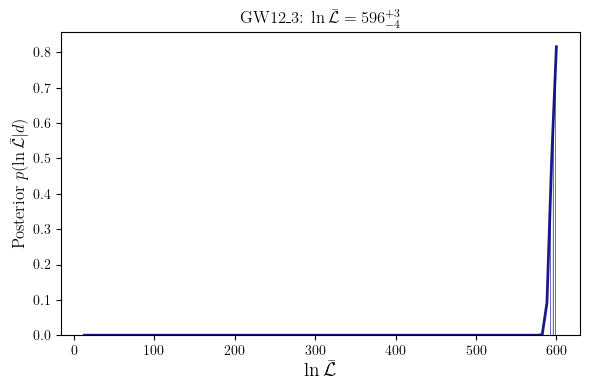

In [16]:
# what's the marginalized lnlike distribution of the lensed and samples?
fig ,ax = plt.subplots(figsize=(6,4), tight_layout=True)
w = samples['weights'][lidx]
hist, edges = np.histogram(lnl_marg, bins=100, weights=w)
# we want the pdf at edges, not midpoints:
pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])

c = 'navy'
ax.plot(edges, pdf, c=c, alpha=0.9, lw=2)
ax.set_ylim(0., None)
ax.set_xlabel(r'$\ln\bar{\mathcal L}$', fontsize=14)
ax.set_ylabel(r'Posterior $p(\ln\bar{\mathcal L}|d)$', fontsize=12)

# vlines
median, *span = helpers.get_samples_median_and_span(samples[lidx], 'lnl_marginalized')
for val in (median, *span):
    ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c=c, alpha=0.8, lw=0.5)
idx = (edges > span[0]) & (edges < span[1])
ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color=c, alpha=0.1)
val_err_str = '${}={}$' + plotting.latex_val_err(median, np.subtract(median, span))
ax.set_title(f'{eventname}: 'r'$\ln\bar{\mathcal L}$' + val_err_str)

In [17]:
# I think the plot looks like this because there are samples with low weight and low ln likelihood, and np.histogram sets its bin range from the min to max of the data regardless of the weights. let's confirm:
print(lnl_marg.min(), lnl_marg.max())
print(f"weight fraction below max-30: {w[lnl_marg < lnl_marg.max() - 30].sum() / w.sum():.2e}")

12.759715081451809 600.0937382986858
weight fraction below max-30: 4.63e-10


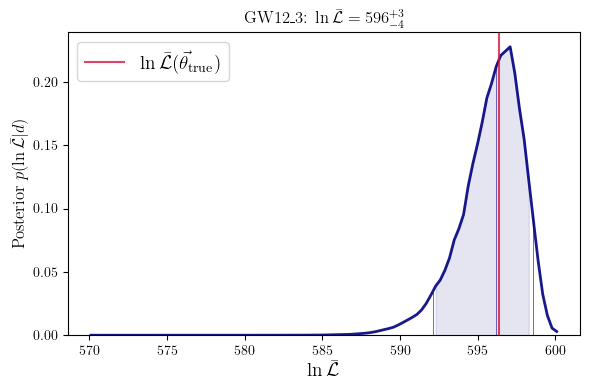

In [18]:
# sweet, let's remake with a different range:
fig ,ax = plt.subplots(figsize=(6,4), tight_layout=True)
lnl_max = lnl_marg.max()
hist, edges = np.histogram(lnl_marg, bins=100,
                            weights=w, range=(lnl_max - 30, lnl_max), density=True)
# we want the pdf at edges, not midpoints:
pdf = np.array([hist[0], *(hist[1:] + hist[:-1]) / 2, hist[-1]])

c = 'navy'
ax.plot(edges, pdf, c=c, alpha=0.9, lw=2)
ax.set_ylim(0., None)
ax.set_xlabel(r'$\ln\bar{\mathcal L}$', fontsize=14)
ax.set_ylabel(r'Posterior $p(\ln\bar{\mathcal L}|d)$', fontsize=12)

# and plot the ln likelihood of the truth
ax.axvline(lnl_true, c='crimson', alpha=0.8, label=r'$\ln\bar{\mathcal L}(\vec\theta_\mathrm{true})$')

# vlines
median, *span = helpers.get_samples_median_and_span(samples[lidx], 'lnl_marginalized')
for val in (median, *span):
    ax.plot([val] * 2, [0, np.interp(val, edges, pdf)], c=c, alpha=0.8, lw=0.5)
idx = (edges > span[0]) & (edges < span[1])
ax.fill_between(edges[idx], np.zeros_like(pdf[idx]), pdf[idx], color=c, alpha=0.1)
val_err_str = '${}={}$' + plotting.latex_val_err(median, np.subtract(median, span))
ax.set_title(f'{eventname}: 'r'$\ln\bar{\mathcal L}$' + val_err_str)
ax.legend(fontsize=14)

In [19]:
# okay I've run this for all of the injections: let's load the results:
nevents = 100
lnBayes = {}
fns = {}
flagged = []
delta_lnls = {}
for idx in range(nevents):
    # load the sampler for this event
    eventname = f'GW{seed}_{idx}'
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
    except FileNotFoundError:
        print(f"no samples for idx {idx}. continuing")
        continue

    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    lnBayes[eventname] = np.load(lnBayes_fn)
    if np.isnan(lnBayes[eventname][0]):
        lnBayes[eventname] = np.array([30., 0.])

    fn = os.path.join(samples_dir, 'lnl_metric.npy')
    fns[eventname] = fn
    lnl_res = np.load(fn, allow_pickle=True).item()
    delta_lnls[eventname] = lnl_res['delta_lnl']
    if lnl_res['delta_lnl'] > 0:
        flagged.append(eventname)
# make an array from the delta_lnl dictionary
delta_lnl_grid = np.array(list(delta_lnls.values()))

loaded posterior samples for GW12_0 run 0
loaded posterior samples for GW12_1 run 0
loaded posterior samples for GW12_2 run 0
loaded posterior samples for GW12_3 run 0
loaded posterior samples for GW12_4 run 0
loaded posterior samples for GW12_5 run 0
loaded posterior samples for GW12_6 run 0
loaded posterior samples for GW12_7 run 0
loaded posterior samples for GW12_8 run 0
loaded posterior samples for GW12_9 run 0
loaded posterior samples for GW12_10 run 0
loaded posterior samples for GW12_11 run 0
loaded posterior samples for GW12_12 run 0
loaded posterior samples for GW12_13 run 0
loaded posterior samples for GW12_14 run 0
loaded posterior samples for GW12_15 run 0
loaded posterior samples for GW12_16 run 0
no samples for idx 17. continuing
loaded posterior samples for GW12_18 run 0
loaded posterior samples for GW12_19 run 0
loaded posterior samples for GW12_20 run 0
loaded posterior samples for GW12_21 run 0
loaded posterior samples for GW12_22 run 0
loaded posterior samples for G

In [20]:
# how many events are flagged?
len(flagged)

0

In [21]:
# how many have a difference in lnlike of -infinity?
idx_neginf = np.isneginf(delta_lnl_grid)
idx_neginf.sum()

np.int64(20)

In [22]:
# what's the min out of the non-infinite cases?
min_delta_lnl = np.min(delta_lnl_grid[~idx_neginf])
print(min_delta_lnl)

-715.0684325676273


Note that we shouldn't get differences this large if we incorporate the sample weights. i.e. the cases with $\Delta\ln\bar{\mathcal L} <<0$ likely have a max likelihood sample with high likelihood but low weight.

Text(0, 0.5, 'Injections')

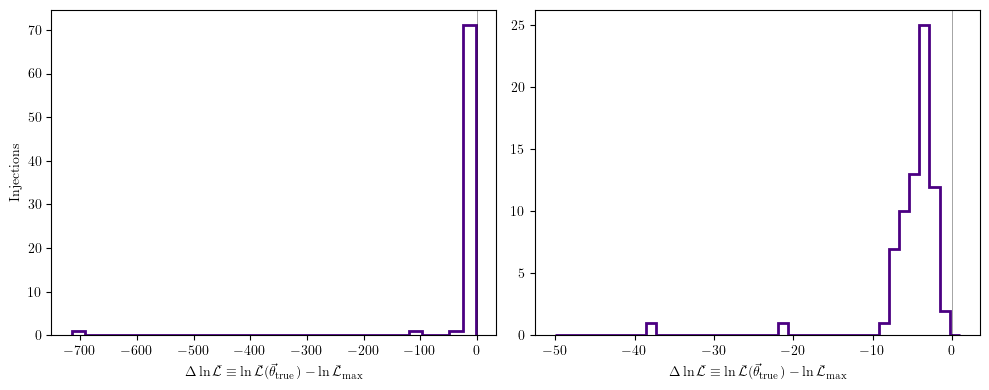

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(10,4), tight_layout=True)
_, _, _ = axs[0].hist(delta_lnl_grid[~idx_neginf], bins=30, color='indigo', histtype='step', lw=2)
bins = np.linspace(-50, 1., 41)
_, _, _ = axs[1].hist(delta_lnl_grid[~idx_neginf], bins=bins, color='indigo', histtype='step', lw=2)
for ax in axs:
    ax.axvline(0., c='k', lw=0.5, alpha=0.5)
    ax.set_xlabel(r'$\Delta\ln\bar{\mathcal L}\equiv\ln\bar{\mathcal L}(\vec\theta_\mathrm{true}) - \ln\bar{\mathcal L}_\mathrm{max}$')
axs[0].set_ylabel('Injections')

In [26]:
np.max(delta_lnl_grid)

np.float64(-1.1899869370245142)

### check relative binning resolution
It doesn't look like the issue is with the sampling itself. The other potential issue was relative binning, in particular the resolution `pn_phase_tol`.

In [6]:
# load a "bad" injection
idx = 14
eventname = f'GW{seed}_{idx}'
event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
# what's the SNR?
snr = np.sqrt(event_data.injection['h_h'].sum())
print(f"SNR is {snr:.1f}")
# load the sampler
sampler = cogwheel.utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
# get the likelihood
like = sampler.posterior.likelihood
# reinstantiate with the unlensed event data
ed_u = event_data.reinstantiate(strain=event_data.strain * -1j)
like_u = like.reinstantiate(event_data=ed_u)

# what is the marginalized likelihood of the true (injected) parameters?
lnl_true = like_u.lnlike(ed_u.injection['par_dic'])
print(f"(marginalized) lnlike of the injected pars is {lnl_true:.1f}")

# and the max marginalized likelihood of the lensed posterior samples?
lidx = samples['lensed']
lnl_marg = samples['lnl_marginalized'][lidx]
lnl_max = lnl_marg.max()
print(f"max (marginalized) lnlike of the lensed posterior samples is {lnl_max:.1f}")

delta_lnl = lnl_true - lnl_max
print(f"(marginalized) ∆lnl = {delta_lnl:.1f}")

loaded posterior samples for GW12_14 run 0
SNR is 62.4


(marginalized) lnlike of the injected pars is 1735.3
max (marginalized) lnlike of the lensed posterior samples is 1832.1
(marginalized) ∆lnl = -96.9


In [7]:
# what about the unmarginalized likelihood?
lnl_full_true = like_u.lnlike_fft(ed_u.injection['par_dic'])
print(f"lnlike of the injected pars is {lnl_full_true:.1f}")
# and of the samples?
lnl_full_max = samples['lnl'][lidx].max()
print(f"max lnlike of the lensed posterior samples is {lnl_full_max:.1f}")
delta_lnl_full = lnl_full_true - lnl_full_max
print(f"∆lnl = {delta_lnl_full:.1f}")

lnlike of the injected pars is 1915.6
max lnlike of the lensed posterior samples is 1871.6
∆lnl = 44.0


This $\Delta\ln\bar{\mathcal L} > 0$ which is an indicator of an issue! but we suspect relative binning is the culprit, since relative binning is involved in drawing extrinsic parameters from the marginalized likelihood for `lnlike_fft()`, but `lnlike()` just gets the marginalized likelihood directly with no relative binning (?).

In [8]:
like_u.pn_phase_tol

0.05

In [9]:
# now reinstantiate with a lower pn_phase_tol and see if the likelihood difference changes
like_u_hires = like_u.reinstantiate(pn_phase_tol=like_u.pn_phase_tol / 2)

In [12]:
lnl_full_true_hires = like_u_hires.lnlike(ed_u.injection['par_dic'])
print(f"(marginalized) lnlike of the injected pars is {lnl_full_true_hires:.1f}")
# and of the samples?
lnl_full_max = samples['lnl_marginalized'][lidx].max()
print(f"max (marginalized) lnlike of the lensed posterior samples is {lnl_full_max:.1f}")
delta_lnl_full_hires = lnl_full_true_hires - lnl_full_max
print(f"(marginalized) ∆lnl = {delta_lnl_full_hires:.1f}")

(marginalized) lnlike of the injected pars is 1723.9
max (marginalized) lnlike of the lensed posterior samples is 1832.1
(marginalized) ∆lnl = -108.2
